# Phase 2: First agent brain

**Skills:** LLM agent orchestration, typed actions, validation, replay.

Phase 2 puts a mind on top of the sim without ever letting it touch sim state directly:

- **Typed intents and a rule-based validator.** The only way to act is to propose `shuttle_nutrients`, `relocate_hyphae` or `set_trade_bias`. Six rule families (authority, geometry, network, resources, bounds, rate) check every proposal: once in the agent's own graph, and again, authoritatively, when the engine applies it.
- **The mycelial network keystone agent,** a LangGraph graph that runs observe → deliberate → propose → validate → commit once a sim-week. It re-deliberates once when the validator rejects something.
- **The Narrator,** a LangGraph graph that turns the event log into a field journal. A fact check rejects any number it didn't get from the facts.
- **A SQLite checkpointer** for both graphs, and **model routing** through Ollama or any OpenAI-compatible server such as vLLM, with a deterministic scripted fallback.

**Done when:** the keystone agent makes validated decisions that change the sim, and replay reproduces them without calling the LLM.

This notebook runs on the **scripted** backend: the sandbox it was built in has no GPU or model server. The scripted policy reads the same observation and answers in the same format as a model, so the graph, parsing, validation and replay paths are identical. To use your local model, see the end.

In [1]:
import os, sys, json, sqlite3
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))

import numpy as np
import matplotlib.pyplot as plt

from cognition import scripted
from cognition.keystone import MyceliumAgent
from cognition.llm import ModelRoute, Router, routes_from_spec
from cognition.narrator import check_entry
from cognition.runner import run_with_agents
from sim import TICKS_PER_YEAR
from sim.engine import Simulation
from sim.patches import patch_sums, region
from sim.replay import replay

router = Router(routes_from_spec("scripted"), scripted=scripted.POLICIES)
art = run_with_agents(42, TICKS_PER_YEAR, router, Path("runs"), "nb_phase2")
sim = art.sim
mine = [i for i in sim.accepted if i.agent == "mycelium"]
print(f"{len(art.mycelium.traces)} decisions, {len(mine)} intents applied, {len(sim.rejected)} refused at apply time")
print({k: sum(i.kind == k for i in mine) for k in ("shuttle_nutrients", "set_trade_bias", "relocate_hyphae")})

52 decisions, 87 intents applied, 0 refused at apply time
{'shuttle_nutrients': 31, 'set_trade_bias': 31, 'relocate_hyphae': 25}


## 1. One decision, end to end

Each decision is recorded in the trace (`runs/<stem>_trace.jsonl`), and that record is exactly what Phase 3's inspector will display. Here is a summer decision.

In [2]:
t = next(t for t in art.mycelium.traces if t["tick"] >= 4200)
obs = t["observation"]
print("DATE        ", obs["date"], "| market active:", obs["market"]["active"])
print("NEEDIEST    ", [(p["patch"], p["plant_cn"], p["n_demand"]) for p in obs["needy_partners"][:3]])
print("RICHEST     ", [(p["patch"], p["sellable_n_g"], p["affordable_n_g_per_hop"]) for p in obs["nutrient_stores"][:3]])
print("COOLING DOWN", obs["cooling_down"])
print("\nDELIBERATION:", t["deliberation"])
print("\nACCEPTED:")
for a in t["accepted"]:
    print("  ", {k: a[k] for k in a if k not in ("tick", "agent")})
print("REJECTED:", t["rejected"] or "none")
print("\nLAST OUTCOMES:", json.dumps(obs["last_outcomes"][:2], indent=1))

DATE         Y1 Jun (day 176) | market active: True
NEEDIEST     [('r6c3', 52.58, 0.43), ('r1c0', 48.76, 0.38), ('r6c2', 49.45, 0.39)]
RICHEST      [('r1c6', 2.52, 96.45), ('r3c7', 1.26, 98.18), ('r2c3', 1.13, 80.51)]
COOLING DOWN ['set_trade_bias->r6c3']

DELIBERATION: Partners in r6c3 are the hungriest (C:N 52.58). I will route stored nutrients to them from the nearest rich patch and lower my price there, and pull hyphae away from contaminated ground.

ACCEPTED:
   {'rationale': 'r6c3 partners need N; r6c6 has spare', 'kind': 'shuttle_nutrients', 'from_patch': 'r6c6', 'to_patch': 'r6c3', 'element': 'n', 'amount_g': 0.356}
REJECTED: none

LAST OUTCOMES: [
 {
  "action": "set trade bias 0.70 in r6c3",
  "patch": "r6c3",
  "plant_cn_then": 51.76,
  "fungal_c_then": 14.64,
  "plant_cn_now": 52.58,
  "fungal_c_now": 15.47
 }
]


## 2. The validator pushes back

The scripted policy no longer makes mistakes (see *What broke*), so this uses a deliberately bad model instead. Its first proposals are a greedy shuttle across the map and an action that doesn't exist. Then it gets the validator's feedback and tries again.

In [3]:
class SloppyModel:
    def __init__(self): self.calls = 0
    def __call__(self, role, messages, context):
        if context["step"] == "deliberate":
            return "Move lots of nitrogen far away."
        self.calls += 1
        if self.calls == 1:
            return json.dumps({"intents": [
                {"kind": "shuttle_nutrients", "from_patch": "r0c0", "to_patch": "r7c7",
                 "element": "n", "amount_g": 500, "rationale": "greedy"},
                {"kind": "summon_rain", "rationale": "not a real action"}]})
        return json.dumps({"intents": [{"kind": "set_trade_bias", "patch": "r3c3", "bias": 0.9,
                                        "rationale": "modest, legal investment"}]})

sloppy = Router({"mycelium": [ModelRoute(backend="scripted")]}, scripted={"mycelium": SloppyModel()})
probe = Simulation(42); probe.run(24 * 150)
agent = MyceliumAgent(sloppy)
committed = agent.decide(probe)
trace = agent.traces[-1]
for r in trace["rejected"]:
    print("REJECTED", r["proposal"].get("kind"))
    for v in r["violations"]:
        print("    -", v)
print("\nattempts:", trace["attempt"], "| committed:", [i.kind for i in committed])

validate: REJECT shuttle 500.00 g N r0c0->r7c7 -> network: r0c0->r7c7 is 14 hops; limit is 3; resources: r0c0 has 0.991 g sellable N; asked for 500.000 (max 90%); resources: transport costs 14000.00 g C but r0c0 can spend at most 166.58


validate: REJECT {'kind': 'summon_rain', 'rationale': 'not a real action'} -> schema:  Input tag 'summon_rain' found using 'kind' does not match any of the expected tags: 'disturb', 'spill', 'shuttle_nutrients', 'relocate_hyphae', 'set_trade_bias'


REJECTED shuttle_nutrients
    - network: r0c0->r7c7 is 14 hops; limit is 3
    - resources: r0c0 has 0.991 g sellable N; asked for 500.000 (max 90%)
    - resources: transport costs 14000.00 g C but r0c0 can spend at most 166.58
REJECTED summon_rain
    - schema:  Input tag 'summon_rain' found using 'kind' does not match any of the expected tags: 'disturb', 'spill', 'shuttle_nutrients', 'relocate_hyphae', 'set_trade_bias'

attempts: 2 | committed: ['set_trade_bias']


All the violations come back at once, so one retry is usually enough. The model can only ever commit what the rules allow.

## 3. Replay never calls a model

The replay record holds every accepted intent with its tick, agent and rationale. Replaying it runs the sim alone. Here the router is booby-trapped to prove it.

In [4]:
def forbidden(*a, **k):
    raise AssertionError("a model was called during replay")
original = Router.complete
Router.complete = forbidden
try:
    again = replay(art.record)
finally:
    Router.complete = original
print("replay bit-identical:", again.state_hash() == art.record.final_hash,
      f"({len(art.record.intents)} agent intents re-applied, 0 model calls)")
print("example recorded rationale:", art.record.intents[5].rationale)

replay bit-identical: True (87 agent intents re-applied, 0 model calls)
example recorded rationale: withdraw hyphae from contaminated soil


## 4. Does the agent help?

The done-when condition only requires that decisions *change* the sim. Whether they *help* is a separate question, and the honest answer comes in two parts.

In [5]:
base = Simulation(42); base.run(TICKS_PER_YEAR)
n = 4096
def summary(s):
    h = s.history
    return {"plant C": s.state.plant.c.mean(), "plant C:N": s.state.plant.c.sum() / s.state.plant.n.sum(),
            "fungal C": s.state.mycorrhiza.c.mean(), "trade C/yr": sum(h["trade_c"]) / n,
            "N bought/yr": sum(h["trade_n"]) / n}
a, b = summary(sim), summary(base)
for k in a:
    print(f"{k:>12}: agent {a[k]:8.2f}   baseline {b[k]:8.2f}   ({(a[k] / b[k] - 1) * 100:+.2f}%)")
print(f"network transport cost: {-sim.ledger.flows('c').get('resp_network_transport', 0) / n:.3f} g C/m2/yr")

     plant C: agent   412.93   baseline   412.35   (+0.14%)
   plant C:N: agent    41.29   baseline    41.36   (-0.17%)
    fungal C: agent    11.98   baseline    12.14   (-1.34%)
  trade C/yr: agent    87.30   baseline    87.80   (-0.57%)
 N bought/yr: agent     4.16   baseline     4.12   (+0.91%)
network transport cost: 0.311 g C/m2/yr


**Meadow-wide, the effect is negligible,** a fraction of a percent. The reason is scale. The shuttles move a few tens of grams of N per patch per week, while a patch's plants hold hundreds of grams, so it's a drop in the bucket.

Locally, though, it might matter. For every shuttle, the next cell compares the target patch's plant N one week later against the same patch in the no-agent baseline.

24 N shuttles, 232.2 g N sent in total
target patches' plant N one week later vs baseline: +229.6 g (99% of what was sent)


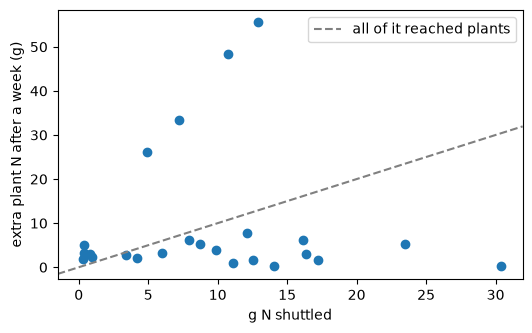

In [6]:
shuttles = [i for i in mine if i.kind == "shuttle_nutrients" and i.element == "n"]
checks = {i.tick + 168: i for i in shuttles}
a_run, b_run = Simulation(42), Simulation(42)
a_run.submit(art.record.intents)
gains = []
for tick in sorted(checks):
    a_run.run_until(tick); b_run.run_until(tick)
    i = checks[tick]
    reg = region(i.to_patch, a_run.state.shape, 8)
    gain = a_run.state.plant.n[reg].sum() - b_run.state.plant.n[reg].sum()
    gains.append((i.amount_g, gain))
sent, got = np.array(gains).T
print(f"{len(gains)} N shuttles, {sent.sum():.1f} g N sent in total")
print(f"target patches' plant N one week later vs baseline: {got.sum():+.1f} g ({got.sum() / sent.sum():.0%} of what was sent)")
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.scatter(sent, got); ax.axline((0, 0), slope=1, ls="--", c="grey", label="all of it reached plants")
ax.set(xlabel="g N shuttled", ylabel="extra plant N after a week (g)"); ax.legend();

**Locally, shuttling works.** Nearly all the shuttled nitrogen reaches the target patch's plants within a week, via the local market, instead of sitting in the fungal store. The mechanism is sound. It's just small next to a whole meadow.

Price cuts are less clear-cut. In the decision shown in section 1, the previous week's cut in r6c3 was followed by plant C:N getting slightly *worse* (51.8 to 52.6). That's the kind of feedback `last_outcomes` surfaces, and that Phase 6's forecast heads should sharpen. The scripted policy ignores it; a model might not.

## 5. The field journal and its fact check

In [7]:
journal = art.paths["journal"].read_text().split("### ")
print("### " + journal[5])
facts = {"rain_mm": 81, "per_m2_now": {"plant_c_g": 298}}
print("fact check, honest:  ", check_entry("81 mm of rain; plants hold 298 g C.", facts) or "passes")
print("fact check, invented:", check_entry("81 mm of rain and 40 new mushrooms.", facts))

### Y1 Apr (day 121) to Y1 May (day 150)

Temperatures ran from 6.3 to 25.5 C with 72 mm of rain. The mycelial network acted: 3 shuttle nutrients, 3 set trade bias, 1 relocate hyphae. Plants now hold about 416 g C per square metre, the fungal network 11.8 g, and plants paid the fungi 15.0 g C per square metre in trade.

*written by scripted:scripted*


fact check, honest:   passes
fact check, invented: ['number 40 is not in the facts']


## 6. Checkpoints

LangGraph writes each agent's state to SQLite after every node. That makes a decision inspectable (and resumable) after the fact.

In [8]:
conn = sqlite3.connect(art.paths["checkpoints"])
for thread, count in conn.execute("select thread_id, count(*) from checkpoints group by thread_id"):
    print(f"{thread:>22}: {count} checkpoints")
cfg = art.mycelium.config
state = art.mycelium.graph.get_state(cfg)
print("latest mycelium checkpoint: tick", state.values["tick"], "| accepted", len(state.values["accepted"]))

    nb_phase2:mycelium: 364 checkpoints
    nb_phase2:narrator: 78 checkpoints
latest mycelium checkpoint: tick 8736 | accepted 2


## What broke (and what got fixed)

The DEBUG log (`runs/<stem>.log`, one event per line) caught all of these.

1. **The cooldown never engaged.** It was 168 ticks, the same as the agent's clock, so "last done 168 ticks ago" never counted as cooling down. The r0c0 price got cut every single week. The cooldown is now 336 ticks (two decisions).
2. **The agent invested in the dead of winter.** It drove r0c0's price to the 0.5 floor in January, when no plant can pay. Observations now include whether the market is active, and the prompt and scripted policy both respect it.
3. **The journal was all agent chatter.** Twelve intent events a month crowded out the storm and the drought. Natural events now come first, and agent actions are summarized as counts.
4. **Journal periods straddled days.** A 730-tick month is 30.4 days, so consecutive entries overlapped. The Narrator now runs every 720 ticks.
5. **Shipments were sized without knowing the cost.** 30 g N over 3 hops costs ~180 g C against a ~120 g budget, and the validator caught it every time. A 7B model would make the same mistake, because the observation never showed the budget. Donors now report `affordable_n_g_per_hop`, and rejections dropped to zero.
6. **The debug log wasn't one-event-per-line.** Pretty-printed observation JSON broke grep and line counts, so observations are now logged as single-line JSON.
7. **Tooling slips.** An edit silently failed to apply because the formatter had reflowed its target, and another spliced text at the wrong place. Every scripted edit now asserts that it matched. A test helper also passed raw dicts where pydantic expected models.

## Known issues

- **The agent's meadow-wide effect is negligible.** That's expected for a heuristic without forecasts. Improving decisions is Phase 6's job.
- **The headless runner pauses the sim while an agent thinks.** Intents apply at tick + 1, but in Phase 3's server the sim will keep running and latency will be real.
- **A real model hasn't been run in this environment.** The HTTP paths are tested against fake Ollama and OpenAI-compatible servers, and a dead server falls back to scripted (logged). Real-model behaviour, speed and JSON reliability still need a run on actual hardware.
- **With a real model, the LLM is the bottleneck, not the sim.** A year makes ~117 model calls. Numba can wait for Phase 4.

## Run it with your local model

```bash
ollama pull qwen2.5:7b-instruct
uv run python -m cognition.run --model ollama:qwen2.5:7b-instruct --ticks 2016 --log-level DEBUG --verify-replay
```

That's 12 weeks, about 25 model calls. Both agents share one model, so a 10 GB card never swaps. For vLLM, use `--model openai:<model> --base-url http://localhost:8000`. If the server is down, the run logs a warning and continues on the scripted policy.